Earliest Start: {'A': 0, 'B': 2, 'C': 2, 'D': 6, 'E': 6, 'F': 10}
Earliest Finish: {'A': 2, 'B': 6, 'C': 5, 'D': 8, 'E': 10, 'F': 13}
Latest Start: {'F': 10, 'E': 6, 'D': 8, 'C': 3, 'B': 2, 'A': 0}
Latest Finish: {'A': 2, 'B': 6, 'C': 6, 'D': 10, 'E': 10, 'F': 13}
Critical Path: ['A', 'B', 'E', 'F']


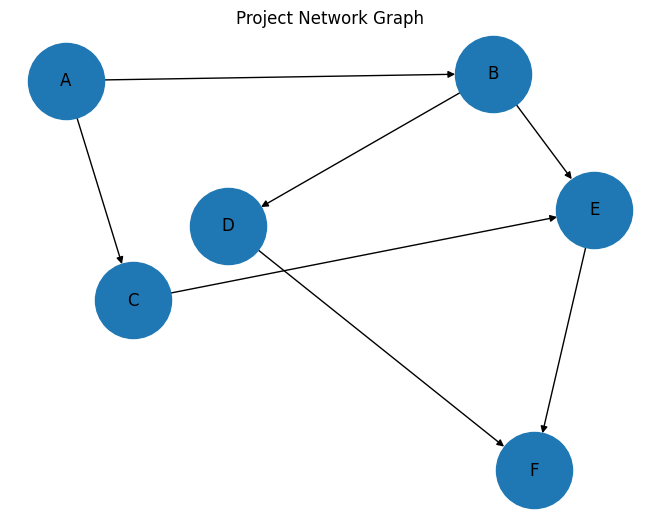

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# Define tasks
tasks = {
    'A': {'duration': 2, 'dependencies': []},
    'B': {'duration': 4, 'dependencies': ['A']},
    'C': {'duration': 3, 'dependencies': ['A']},
    'D': {'duration': 2, 'dependencies': ['B']},
    'E': {'duration': 4, 'dependencies': ['B', 'C']},
    'F': {'duration': 3, 'dependencies': ['D', 'E']}
}

# -------------------------------
# Create graph
G = nx.DiGraph()

for task, data in tasks.items():
    G.add_node(task, duration=data['duration'])
    for dep in data['dependencies']:
        G.add_edge(dep, task)

# -------------------------------
# Topological order
topo_order = list(nx.topological_sort(G))

# -------------------------------
# Forward pass (Earliest times)
earliest_start = {task: 0 for task in topo_order}
earliest_finish = {}

for task in topo_order:
    earliest_finish[task] = earliest_start[task] + G.nodes[task]['duration']
    for succ in G.successors(task):
        earliest_start[succ] = max(earliest_start[succ], earliest_finish[task])

# -------------------------------
# Backward pass (Latest times)
latest_finish = {task: max(earliest_finish.values()) for task in topo_order}
latest_start = {}

for task in reversed(topo_order):
    latest_start[task] = latest_finish[task] - G.nodes[task]['duration']
    for pred in G.predecessors(task):
        latest_finish[pred] = min(latest_finish[pred], latest_start[task])

# -------------------------------
# Critical Path
critical_path = [t for t in topo_order if earliest_start[t] == latest_start[t]]

# -------------------------------
# Output
print("Earliest Start:", earliest_start)
print("Earliest Finish:", earliest_finish)
print("Latest Start:", latest_start)
print("Latest Finish:", latest_finish)
print("Critical Path:", critical_path)

# -------------------------------
# Plot graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000)
plt.title("Project Network Graph")
plt.show()